## Упражнение 05. Диаграмма размаха (boxplot)

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/ab-test.csv')
df

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test
5,user_19,-148.000000,before,test
6,user_21,-78.500000,after,test
7,user_21,-112.500000,before,test
8,user_25,-127.500000,after,test
9,user_25,-69.333333,before,test


In [4]:
df_after = df[df["time"] == "after"].drop(columns=["uid", "time", ], )
df_before = df[df["time"] == "before"].drop(columns=["uid", "time", ], )
df_after

,diff,group
0,-103.333333,test
2,-10.000000,test
4,-82.333333,test
6,-78.500000,test
8,-127.500000,test
10,-136.500000,test
12,-158.500000,test
14,-75.000000,control
16,-81.500000,control
18,-32.000000,control


In [5]:
df_before

,diff,group
1,-6.000000,test
3,-3.500000,test
5,-148.000000,test
7,-112.500000,test
9,-69.333333,test
11,-53.000000,test
13,-70.000000,test
15,-103.000000,control
17,-15.500000,control
19,-3.000000,control


In [6]:
df_before_test = df_before[df_before["group"] == "test"].drop(columns=["group", ], )
df_before_ctrl = df_before[df_before["group"] == "control"].drop(columns=["group", ], )
df_after_test = df_after[df_after["group"] == "test"].drop(columns=["group", ], )
df_after_ctrl = df_after[df_after["group"] == "control"].drop(columns=["group", ], )

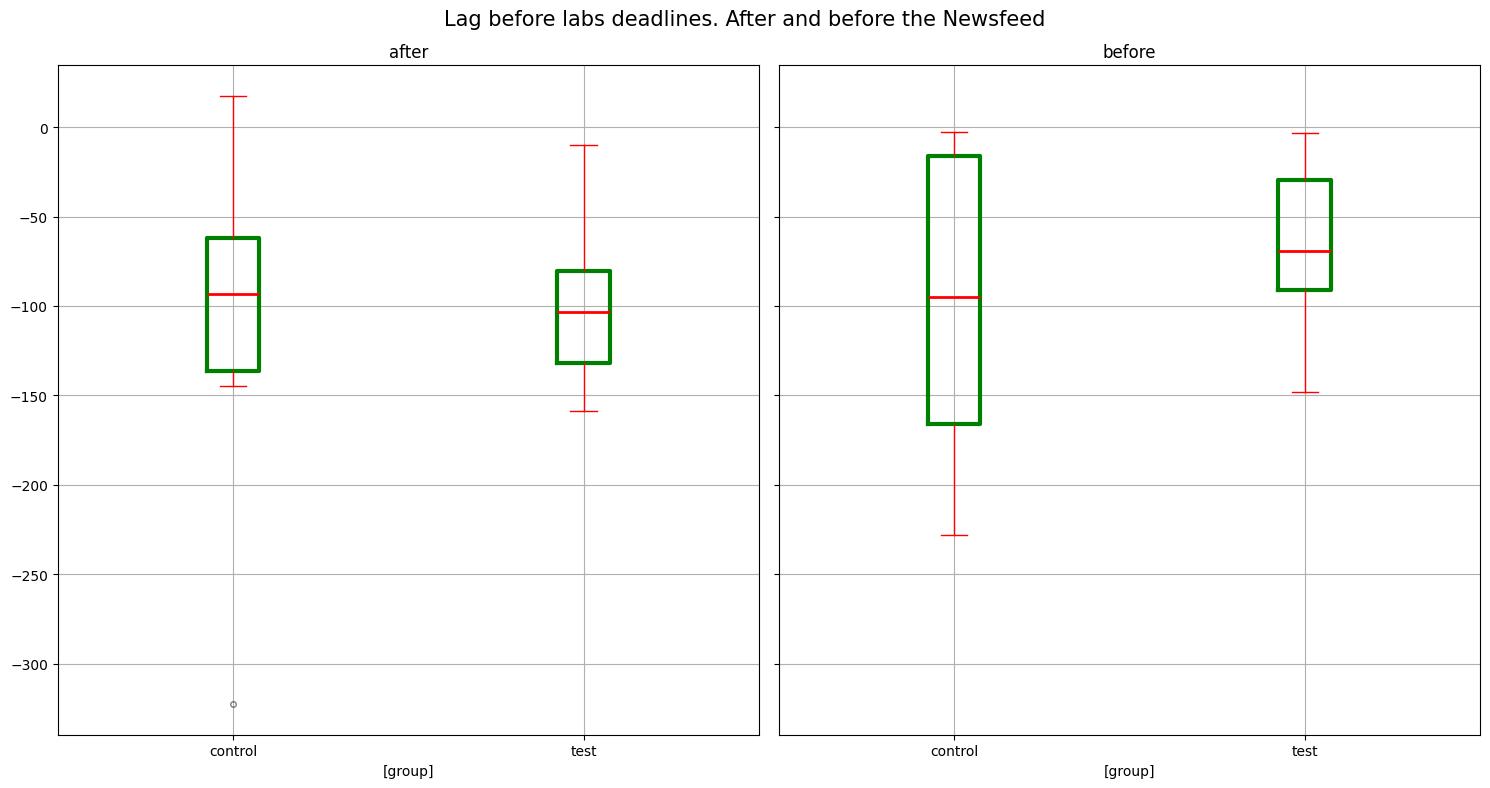

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

df_after.boxplot(
    column='diff',
    by='group',
    ax=axes[0],
    boxprops=dict(color='green', linewidth=3),
    whiskerprops=dict(color='red'),
    capprops=dict(color='red'),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='black', alpha=0.5, markersize=4)
)
axes[0].set_title('after')
axes[0].set_xlabel('[group]')
axes[0].set_ylabel('')
df_before.boxplot(
    column='diff',
    by='group',
    ax=axes[1],
    boxprops=dict(color='green', linewidth=3),
    whiskerprops=dict(color='red'),
    capprops=dict(color='red'),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='black', alpha=0.5, markersize=4)
)
axes[1].set_title('before')
axes[1].set_xlabel('[group]')
axes[1].set_ylabel('')
plt.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)
plt.tight_layout()
plt.show()

### Каков IQR (межквартильный размах) контрольной группы до появления ленты новостей?

In [11]:
iqr_series = df_before_ctrl.quantile(0.75) - df_before_ctrl.quantile(0.25)
print(iqr_series)

diff    150.0
dtype: float64
